# 5. EVALUASI SISTEM REKOMENDASI

**Ekstraksi Kata Kunci dengan N-Gram dan IndoBERT untuk Rekomendasi Wisata Bogor**

---

Evaluasi dengan bobot **50% N-gram + 50% IndoBERT**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = './data/'
print(" Libraries imported!")

 Libraries imported!


In [2]:
# Load data
df = pd.read_csv(f'{DATA_PATH}data_with_keywords.csv')
ngram_sim = np.load(f'{DATA_PATH}ngram_similarity.npy')
indobert_sim = np.load(f'{DATA_PATH}indobert_similarity.npy')
combined_sim = np.load(f'{DATA_PATH}combined_similarity.npy')

info_df = pd.DataFrame({
    'Data': ['Jumlah Wisata', 'Jumlah Kategori', 'N-gram Matrix', 'IndoBERT Matrix', 'Combined Matrix'],
    'Nilai': [len(df), df['kategori'].nunique(), str(ngram_sim.shape), str(indobert_sim.shape), str(combined_sim.shape)]
})
print("TABEL: DATA DIMUAT")
display(info_df)

TABEL: DATA DIMUAT


,Data,Nilai
0,Jumlah Wisata,296
1,Jumlah Kategori,7
2,N-gram Matrix,"(296, 296)"
3,IndoBERT Matrix,"(296, 296)"
4,Combined Matrix,"(296, 296)"


## 5.1 Evaluasi Precision, Recall, F1-Score

In [3]:
def evaluate_method(similarity_matrix, top_n=5):
    """Evaluasi berdasarkan category matching"""
    categories = df['kategori'].values
    precisions, recalls, f1_scores = [], [], []
    
    for idx in range(len(df)):
        source_cat = categories[idx]
        relevant = set(np.where(categories == source_cat)[0]) - {idx}
        
        if len(relevant) == 0:
            continue
        
        scores = similarity_matrix[idx]
        top_idx = set(np.argsort(scores)[::-1][1:top_n+1])
        
        tp = len(relevant.intersection(top_idx))
        precision = tp / top_n
        recall = tp / len(relevant)
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)
    
    return np.mean(precisions), np.mean(recalls), np.mean(f1_scores)

In [4]:
# Evaluasi semua metode
results = []

for top_n in [3, 5, 10]:
    p1, r1, f1 = evaluate_method(ngram_sim, top_n)
    results.append({'Metode': 'N-gram + TF-IDF', 'Top-N': top_n, 'Precision': round(p1, 4), 'Recall': round(r1, 4), 'F1-Score': round(f1, 4)})
    
    p2, r2, f2 = evaluate_method(indobert_sim, top_n)
    results.append({'Metode': 'IndoBERT', 'Top-N': top_n, 'Precision': round(p2, 4), 'Recall': round(r2, 4), 'F1-Score': round(f2, 4)})
    
    p3, r3, f3 = evaluate_method(combined_sim, top_n)
    results.append({'Metode': 'N-gram + IndoBERT', 'Top-N': top_n, 'Precision': round(p3, 4), 'Recall': round(r3, 4), 'F1-Score': round(f3, 4)})

eval_df = pd.DataFrame(results)

In [5]:
# TABEL 1: Perbandingan Lengkap
print("TABEL 1: PERBANDINGAN PERFORMA METODE (Top-3, Top-5, Top-10)")
display(eval_df)

TABEL 1: PERBANDINGAN PERFORMA METODE (Top-3, Top-5, Top-10)


,Metode,Top-N,Precision,Recall,F1-Score
0,N-gram + TF-IDF,3,0.6340,0.0406,0.0723
1,IndoBERT,3,0.4550,0.0242,0.0445
2,N-gram + IndoBERT,3,0.6340,0.0406,0.0723
3,N-gram + TF-IDF,5,0.6074,0.0614,0.1040
4,IndoBERT,5,0.4236,0.0369,0.0649
5,N-gram + IndoBERT,5,0.6081,0.0615,0.1041
6,N-gram + TF-IDF,10,0.5764,0.1100,0.1697
7,IndoBERT,10,0.3892,0.0655,0.1060
8,N-gram + IndoBERT,10,0.5760,0.1100,0.1696


In [6]:
# TABEL 2: Top-5 dengan Improvement
top5_df = eval_df[eval_df['Top-N'] == 5][['Metode', 'Precision', 'Recall', 'F1-Score']].reset_index(drop=True)

baseline_f1 = top5_df[top5_df['Metode'] == 'N-gram + TF-IDF']['F1-Score'].values[0]
top5_df['Improvement vs Baseline'] = ((top5_df['F1-Score'] - baseline_f1) / baseline_f1 * 100).round(2)
top5_df['Improvement vs Baseline'] = top5_df['Improvement vs Baseline'].apply(lambda x: f"+{x}%" if x > 0 else f"{x}%")

print("\nTABEL 2: PERBANDINGAN METODE (Top-5) DENGAN IMPROVEMENT")
display(top5_df)


TABEL 2: PERBANDINGAN METODE (Top-5) DENGAN IMPROVEMENT


,Metode,Precision,Recall,F1-Score,Improvement vs Baseline
0,N-gram + TF-IDF,0.6074,0.0614,0.1040,0.0%
1,IndoBERT,0.4236,0.0369,0.0649,-37.6%
2,N-gram + IndoBERT,0.6081,0.0615,0.1041,+0.1%


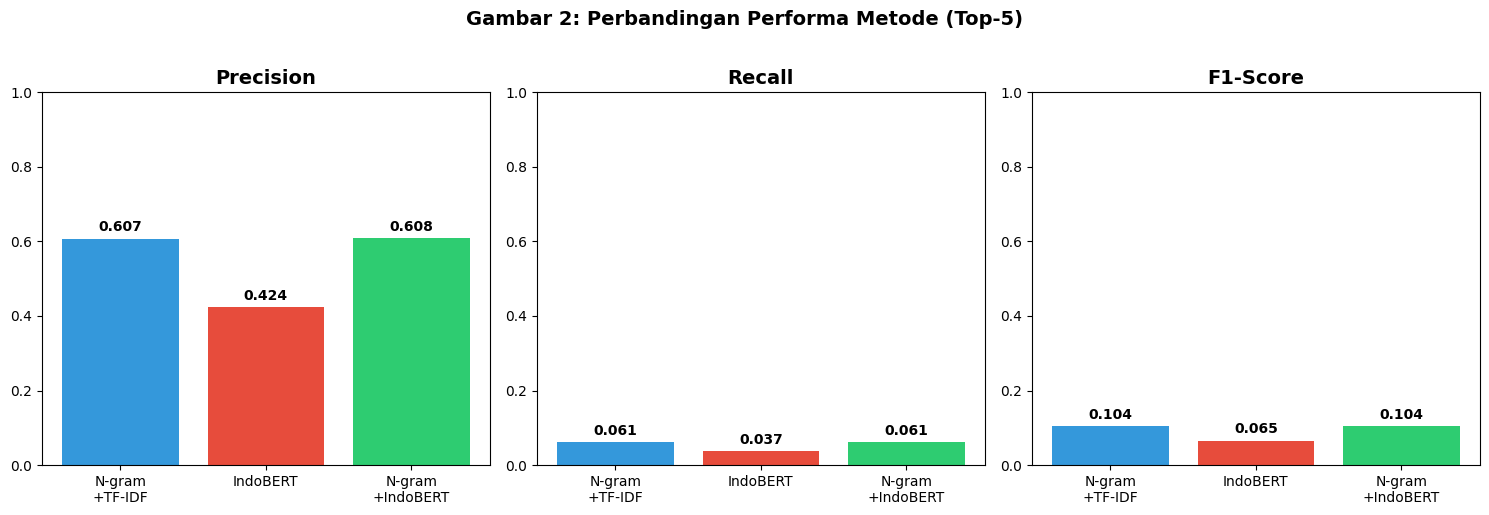

In [7]:
# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71']
methods = ['N-gram\n+TF-IDF', 'IndoBERT', 'N-gram\n+IndoBERT']

for i, metric in enumerate(metrics):
    values = top5_df[metric].values
    bars = axes[i].bar(range(len(methods)), values, color=colors)
    axes[i].set_title(metric, fontweight='bold', fontsize=14)
    axes[i].set_ylim(0, 1)
    axes[i].set_xticks(range(len(methods)))
    axes[i].set_xticklabels(methods, fontsize=10)
    
    for bar, v in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Gambar 2: Perbandingan Performa Metode (Top-5)', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_PATH}evaluation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.2 Confusion Matrix

In [8]:
def category_confusion_matrix(similarity_matrix):
    """Create category-based confusion matrix (Top-1)"""
    categories = df['kategori'].values
    unique_cats = sorted(df['kategori'].unique())
    n_cats = len(unique_cats)
    
    cm = np.zeros((n_cats, n_cats), dtype=int)
    cat_to_idx = {cat: idx for idx, cat in enumerate(unique_cats)}
    
    for idx in range(len(df)):
        source_cat = categories[idx]
        source_idx = cat_to_idx[source_cat]
        
        top_rec = np.argsort(similarity_matrix[idx])[::-1][1]
        rec_cat = categories[top_rec]
        rec_idx = cat_to_idx[rec_cat]
        
        cm[source_idx, rec_idx] += 1
    
    return cm, unique_cats

cm_ngram, cats = category_confusion_matrix(ngram_sim)
cm_bert, _ = category_confusion_matrix(indobert_sim)
cm_comb, _ = category_confusion_matrix(combined_sim)

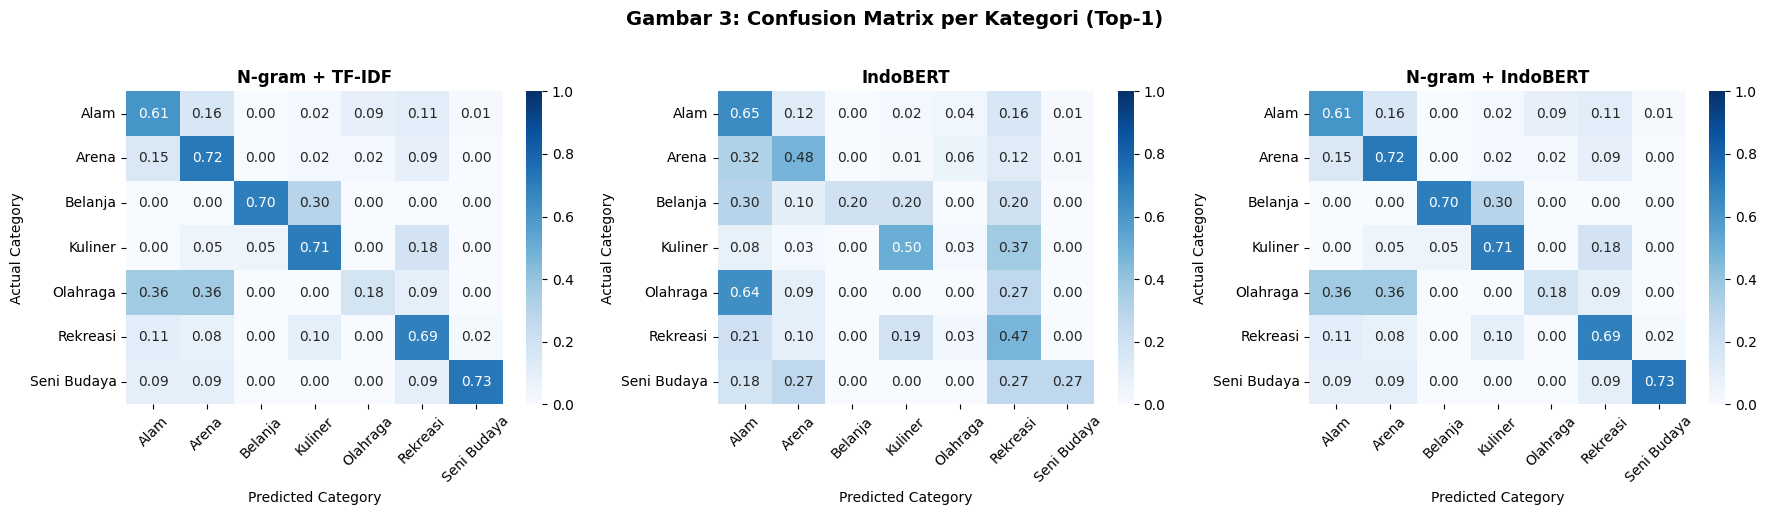

In [9]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cms = [cm_ngram, cm_bert, cm_comb]
titles = ['N-gram + TF-IDF', 'IndoBERT', 'N-gram + IndoBERT']

for ax, cm, title in zip(axes, cms, titles):
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_norm = np.nan_to_num(cm_norm)
    
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', 
                xticklabels=cats, yticklabels=cats, ax=ax, vmin=0, vmax=1)
    ax.set_title(f'{title}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted Category')
    ax.set_ylabel('Actual Category')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Gambar 3: Confusion Matrix per Kategori (Top-1)', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_PATH}confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# TABEL 3: Akurasi per Kategori
cat_accuracy = []
for i, cat in enumerate(cats):
    total = cm_ngram[i].sum()
    if total > 0:
        cat_accuracy.append({
            'Kategori': cat,
            'Jumlah Data': int(total),
            'N-gram+TF-IDF': f"{cm_ngram[i,i]/total:.2%}",
            'IndoBERT': f"{cm_bert[i,i]/total:.2%}",
            'N-gram+IndoBERT': f"{cm_comb[i,i]/total:.2%}"
        })

cat_acc_df = pd.DataFrame(cat_accuracy)
print("TABEL 3: AKURASI PER KATEGORI (Top-1)")
display(cat_acc_df)

TABEL 3: AKURASI PER KATEGORI (Top-1)


,Kategori,Jumlah Data,N-gram+TF-IDF,IndoBERT,N-gram+IndoBERT
0,Alam,82,60.98%,64.63%,60.98%
1,Arena,82,71.95%,47.56%,71.95%
2,Belanja,10,70.00%,20.00%,70.00%
3,Kuliner,38,71.05%,50.00%,71.05%
4,Olahraga,11,18.18%,0.00%,18.18%
5,Rekreasi,62,69.35%,46.77%,69.35%
6,Seni Budaya,11,72.73%,27.27%,72.73%


In [11]:
# TABEL 4: Overall Accuracy
acc_ngram = np.trace(cm_ngram) / cm_ngram.sum()
acc_bert = np.trace(cm_bert) / cm_bert.sum()
acc_comb = np.trace(cm_comb) / cm_comb.sum()

overall_acc = pd.DataFrame({
    'Metode': ['N-gram + TF-IDF', 'IndoBERT', 'N-gram + IndoBERT'],
    'Overall Accuracy': [f"{acc_ngram:.2%}", f"{acc_bert:.2%}", f"{acc_comb:.2%}"],
    'Keterangan': ['Lexical Only', 'Semantic Only', 'Combined (50:50)']
})
print("\nTABEL 4: OVERALL ACCURACY (Top-1)")
display(overall_acc)


TABEL 4: OVERALL ACCURACY (Top-1)


,Metode,Overall Accuracy,Keterangan
0,N-gram + TF-IDF,66.22%,Lexical Only
1,IndoBERT,48.99%,Semantic Only
2,N-gram + IndoBERT,66.22%,Combined (50:50)


## 5.3 Kesimpulan

In [12]:
# TABEL 5: Kesimpulan
best_method = top5_df.loc[top5_df['F1-Score'].idxmax()]

conclusion = pd.DataFrame({
    'Aspek': [
        'Metode Terbaik',
        'F1-Score Tertinggi',
        'Precision',
        'Recall',
        'Improvement vs Baseline',
        'Bobot Kombinasi'
    ],
    'Hasil': [
        best_method['Metode'],
        f"{best_method['F1-Score']:.4f}",
        f"{best_method['Precision']:.4f}",
        f"{best_method['Recall']:.4f}",
        best_method['Improvement vs Baseline'],
        '50% N-gram + 50% IndoBERT'
    ]
})
print("TABEL 5: KESIMPULAN EVALUASI")
display(conclusion)

TABEL 5: KESIMPULAN EVALUASI


,Aspek,Hasil
0,Metode Terbaik,N-gram + IndoBERT
1,F1-Score Tertinggi,0.1041
2,Precision,0.6081
3,Recall,0.0615
4,Improvement vs Baseline,+0.1%
5,Bobot Kombinasi,50% N-gram + 50% IndoBERT


In [ ]:
# Export CSV
eval_df.to_csv(f'{DATA_PATH}tabel_perbandingan.csv', index=False)
cat_acc_df.to_csv(f'{DATA_PATH}tabel_akurasi_kategori.csv', index=False)

exported = pd.DataFrame({
    'File': ['tabel_perbandingan.csv', 'tabel_akurasi_kategori.csv', 'evaluation_comparison.png', 'confusion_matrix.png'],
    'Deskripsi': ['Precision, Recall, F1-Score', 'Akurasi per kategori', 'Chart perbandingan', 'Confusion matrix']
})
print("\nTABEL: FILES EXPORTED")
display(exported)


TABEL: FILES EXPORTED


,File,Deskripsi
0,tabel_perbandingan.csv,"Precision, Recall, F1-Score"
1,tabel_akurasi_kategori.csv,Akurasi per kategori
2,evaluation_comparison.png,Chart perbandingan
3,confusion_matrix.png,Confusion matrix


: 